# Introduction to Polynomial Regression

Polynomial regression helps us model curved patterns while still using linear regression as the core estimator.

- Real-world relationships are often nonlinear.
- A plain linear model may underfit when the pattern is curved.
- Polynomial features can improve fit, but they can also increase overfitting risk.

### Learning Goals

This guide will let us:

- Explain underfitting vs overfitting using train/test behavior.
- Create polynomial features and interpret what they mean.
- Compare model quality using both $R^2$ and MSE on train and test sets.
- Use pipelines and cross-validation to choose model complexity responsibly.

### Vocabulary Recap

- **Underfitting**: model is too simple; misses core pattern.
- **Overfitting**: model memorizes noise; test performance drops.
- **Polynomial feature**: transformed feature such as $x^2$ or interaction terms.
- **Generalization**: performance on unseen data, not just training data.

### Getting the most out of this notebook

- Run one section at a time, then pause to interpret train vs test metrics.
- If train performance rises but test performance falls, mark it as potential overfitting.
- Keep a short experiment log: degree used, train metric, test metric, conclusion.

***


### Workflow Plan

This guide is built on the previous guides, and continues the same evaluation logic from the train-test split lab and adds model complexity analysis.

1. Start with a reliable split to estimate generalization.
2. Fit a baseline linear model and record train/test metrics. Train only on training data, and predict on unseen test data.
3. Add polynomial features to capture curvature.
4. Track how complexity changes train error and test error. Evaluate with a metric, then compare alternatives.
5. Use validation and cross-validation to pick degree/hyperparameters.
6. Avoid data leakage and over-claiming model quality.
7. Prefer the simplest model that generalizes well.

#### Decision Checklist

At each modeling step, ask:
- Did test performance improve in a stable way?
- Is the complexity increase justified by better generalization?
- Can I explain this choice to a non-technical stakeholder?

In [60]:
# All libraries required for this lab are listed below.  # explain purpose of this cell
# !pip install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1  # uncomment to install the required packages in one command

In [61]:
"""
!pip install -U scikit-learn
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn
"""

'\n!pip install -U scikit-learn\n!pip install pandas\n!pip install numpy\n!pip install seaborn\n!pip install matplotlib\n!pip install scikit-learn\n'

In [62]:
# Suppress warnings in notebook output for cleaner display.
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn


In [63]:
import pandas as pd  
import numpy as np 

import matplotlib.pylab as plt
import seaborn as sns 
%matplotlib inline

from sklearn.model_selection import train_test_split  # split data into train and test sets
from sklearn.linear_model import LinearRegression  # linear regression model
from sklearn.metrics import r2_score  # R-squared evaluation metric
from sklearn.metrics import mean_squared_error  # mean squared error metric

from sklearn.preprocessing import PolynomialFeatures  # create polynomial feature terms
from sklearn.preprocessing import scale, StandardScaler, MinMaxScaler # data scaling utilities
from sklearn.feature_selection import SelectKBest, f_regression  # feature selection utilities
from sklearn.pipeline import Pipeline  # chain preprocessing and model steps
from sklearn.model_selection import GridSearchCV  # hyperparameter search with cross-validation

## **Reading and understanding our data**


For this lab, we will be using a car-sales dataset; please download it from the [data folder](https://github.com/Souvik-Mandal-Harvard/Machine-Learning-for-Data-Science/blob/af1d8d0ec7e227c950719e5592449f561167ce69/supervised-ML/data/encoded_car_data.csv) of this repo. The original data is hosted on [kaggle.com](https://www.kaggle.com/datasets/goyalshalini93/car-data).

The dataset includes car characteristics (technical and categorical attributes) and a target column: `price`.

This notebook uses a pre-cleaned and pre-encoded version of the data, prepared in the linear-regression workflow.

**Note**: Because encoding is already done, this notebook focuses on model behavior (especially complexity) rather than raw preprocessing steps.

Let's read the data into *pandas* data frame and look at the first 5 rows using the `head()` method.


In [64]:
data = pd.read_csv('data/encoded_car_data.csv')
data.head()

,diesel,gas,std,turbo,convertible,hardtop,hatchback,sedan,wagon,4wd,...,wheelbase,curbweight,enginesize,boreratio,horsepower,carlength,carwidth,citympg,highwaympg,price
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,13495.0
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,16500.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,94.5,2823.0,152.0,2.68,154.0,171.2,65.5,19.0,26.0,16500.0
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,99.8,2337.0,109.0,3.19,102.0,176.6,66.2,24.0,30.0,13950.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,99.4,2824.0,136.0,3.19,115.0,176.6,66.4,18.0,22.0,17450.0


We can find more information about the features and types using the `info()`  method.


In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 36 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   diesel       205 non-null    float64
 1   gas          205 non-null    float64
 2   std          205 non-null    float64
 3   turbo        205 non-null    float64
 4   convertible  205 non-null    float64
 5   hardtop      205 non-null    float64
 6   hatchback    205 non-null    float64
 7   sedan        205 non-null    float64
 8   wagon        205 non-null    float64
 9   4wd          205 non-null    float64
 10  fwd          205 non-null    float64
 11  rwd          205 non-null    float64
 12  dohc         205 non-null    float64
 13  dohcv        205 non-null    float64
 14  l            205 non-null    float64
 15  ohc          205 non-null    float64
 16  ohcf         205 non-null    float64
 17  ohcv         205 non-null    float64
 18  rotor        205 non-null    float64
 19  eight   

We have 35 features in our dataset after the one hot encoding. 

Before we begin our polynomial analysis, let's visualize some of the relationships between our features and the target variable, 'price'.


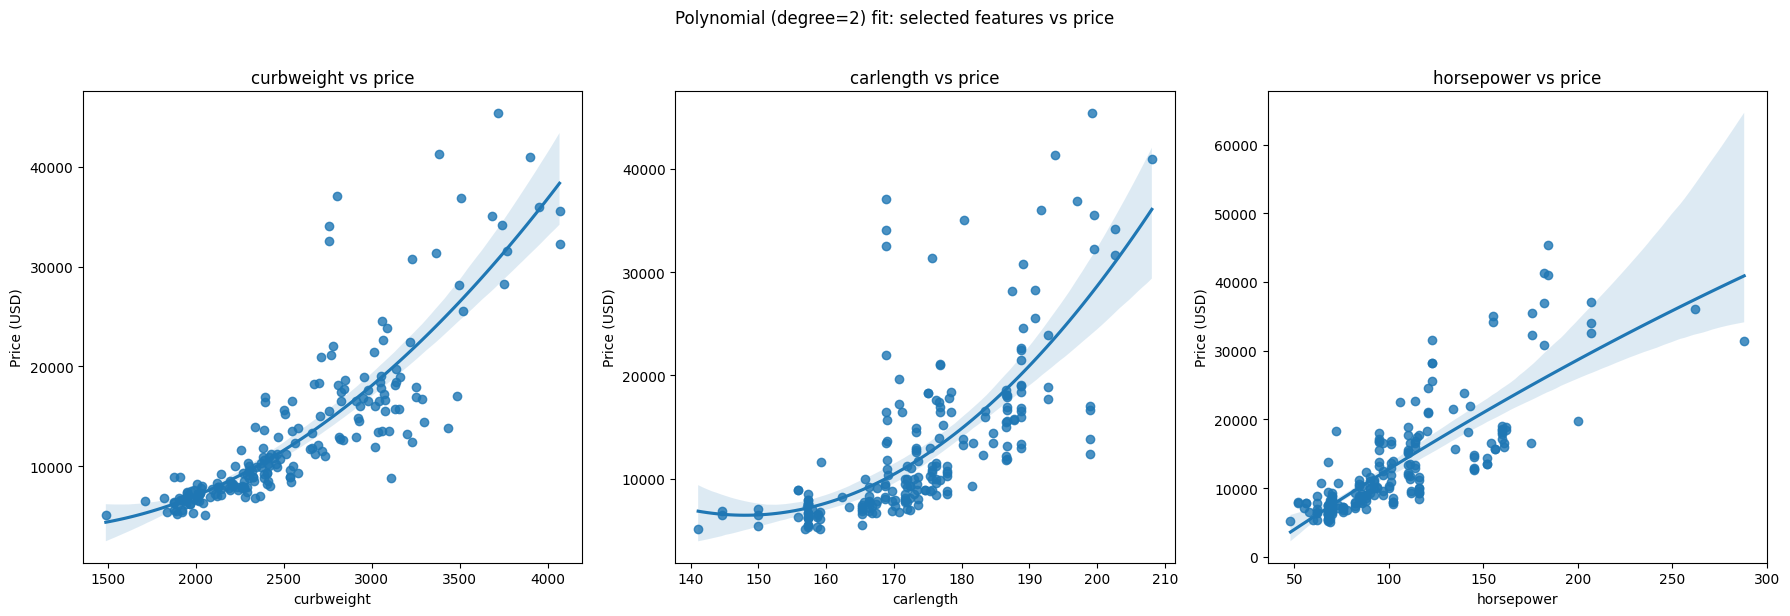

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, feature in zip(axes, ['curbweight', 'carlength', 'horsepower']):
    sns.regplot(x=feature, y='price', data=data, order=2, ax=ax)
    ax.set_title(f'{feature} vs price')
    ax.set_xlabel(feature)
    ax.set_ylabel('Price (USD)')

plt.suptitle('Polynomial (degree=2) fit: selected features vs price', y=1.02)
plt.tight_layout()
plt.show()


All three features show a curved relationship with `price`, suggesting a polynomial model may fit better than a straight line. Notice that `curbweight` and `horsepower` have relatively tight bands, while `carlength` has more scatter — a hint that `carlength` alone may be a weaker predictor.


## Data Preparation

Let's first split our data into ```X``` features and ```y``` target.


In [67]:
X = data.drop('price', axis=1)
y = data.price

## Train Test Split 


Now that we have split our data into training and testing sets, the training set is used to learn model patterns, while the test set is used to evaluate how well the model generalizes to unseen data.


Now, we split our data, using <code>train_test_split</code> function, into the training and testing sets, allocating 30% of the data for testing.


In [68]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=1242)
print("Number of test samples:", X_test.shape[0])
print("Number of training samples:", X_train.shape[0])


Number of test samples: 62
Number of training samples: 143


### Auditing rare indicator columns before analysis

After splitting the data, it is good practice to audit binary (0/1) indicator columns for extreme sparsity **before** building feature-by-feature plots or $R^2$ comparisons.

**Why it matters for single-feature analysis**: when a column has almost no positive examples, fitting a model on that column alone is unreliable — the model is effectively trained on a nearly constant input, and the resulting $R^2$ is noisy and non-representative.

**Decision rule used here**: flag any binary indicator whose positive rate is below **1%** (i.e., fewer than ~2 positive rows in our 205-row dataset). The next code cell prints and highlights all such columns so you can make an evidence-based decision about whether to include them.


In [69]:
# Identify binary (0/1) indicator columns and compute their positive rate on the full dataset
binary_cols = [col for col in X.columns if X[col].dropna().isin([0, 1]).all()]

rare_threshold = 0.01  # flag columns where < 1% of rows are positive

sparsity = (
    X[binary_cols]
    .mean()
    .rename("positive_rate")
    .to_frame()
    .assign(rare=lambda df: df["positive_rate"] < rare_threshold)
    .sort_values("positive_rate")
)

print(f"Binary indicator columns: {len(binary_cols)}")
print(f"Rare indicators (positive_rate < {rare_threshold*100:.0f}%): "
      f"{sparsity['rare'].sum()}\n")

sparsity.style.format({"positive_rate": "{:.2%}"}).applymap(
    lambda v: "background-color: #ffe0e0" if v else "", subset=["rare"]
)


Binary indicator columns: 26
Rare indicators (positive_rate < 1%): 3



,positive_rate,rare
three,0.49%,True
dohcv,0.49%,True
twelve,0.49%,True
two,1.95%,False
rotor,1.95%,False
eight,2.44%,False
convertible,2.93%,False
hardtop,3.90%,False
4wd,4.39%,False
five,5.37%,False


### Why we need a helper function here
Before moving to pipelines and polynomial models, we want one consistent way to answer this question:
**"How well does each feature perform by itself?"**

Doing this manually for every column would require repeating the same fit/score/plot steps many times and increases the chance of mistakes. So we define `get_single_feature_r2()` once and reuse it.

### What this function does
- Trains the provided model on **one feature at a time** (`X_train[[feature]]`)
- Computes train and test $R^2$ for each single-feature model
- Plots all single-feature scores in one chart
- Prints summary statistics (mean and max $R^2$)

### Important
The outputs from this function are **single-feature** results. They are not directly comparable to scores from a model trained on **all features together** (like the baseline and pipeline all-feature cells).

### Rare-indicator rule used inside the function
For single-feature analysis, we exclude ultra-rare binary indicators (positive rate < 1%) because their standalone $R^2$ can be unstable and misleading. This rule improves interpretability for feature-by-feature comparison.

In [70]:
def get_single_feature_r2(model, test=True):
    """Evaluate train/test R^2 for one-feature-at-a-time models and plot the results."""
    features = list(X)

    # Use data-driven rare-feature exclusions from the audit table when available.
    # Fallback keeps behavior stable even if the audit cell has not been run yet.
    if "sparsity" in globals() and {"rare"}.issubset(sparsity.columns):
        rare_features = sparsity.index[sparsity["rare"]].tolist()
    else:
        rare_features = ["three", "dohcv", "twelve"]

    excluded_features = [f for f in rare_features if f in features]
    features = [f for f in features if f not in excluded_features]

    R_2_train = []
    R_2_test = []

    for feature in features:
        model.fit(X_train[[feature]], y_train)
        R_2_test.append(model.score(X_test[[feature]], y_test))
        R_2_train.append(model.score(X_train[[feature]], y_train))

    plt.bar(features, R_2_train, label="Train")
    plt.bar(features, R_2_test, label="Test")
    plt.xticks(rotation=90)
    plt.ylabel("$R^2$")
    plt.legend()
    plt.show()

    if excluded_features:
        print("Excluded ultra-rare indicators:", excluded_features)

    print("Training R^2 mean value {} Testing R^2 mean value {} ".format(str(np.mean(R_2_train)), str(np.mean(R_2_test))))
    print("Training R^2 max value {} Testing R^2 max value {} ".format(str(np.max(R_2_train)), str(np.max(R_2_test))))

### Helper function 2: `plot_dis`

We define this helper after data loading and splitting so its purpose is clear: compare the distribution of predictions against actual values on a known dataset split.

In [71]:
def plot_dis(y, yhat):
    plt.figure()
    ax1 = sns.distplot(y, hist=False, color="r", label="Actual Value")
    sns.distplot(yhat, hist=False, color="b", label="Fitted Values", ax=ax1)
    plt.legend()

    plt.title('Actual vs Fitted Values')
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')

    plt.show()
    plt.close()

### Baseline Linear Regression with All Features

We start by fitting a simple linear regression model using all available input features. This gives us a baseline to compare against later pipeline and polynomial models.


In [72]:
baseline_all_features_lm = LinearRegression()

Now we train the model with multiple features using `X_train` and `y_train`.

### What you are about to do: 
- Fit (train) a linear regression model on the training split.
- **Technical term - Fit**: The process of learning model parameters from data. Example: `lm.fit(X_train, y_train)` learns feature weights.

In [73]:
baseline_all_features_lm.fit(X_train, y_train)  # fit the linear regression model on the training data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Now we apply the `predict()` function on the testing set to estimate car prices for unseen examples.

This step uses the trained model to convert feature rows in `X_test` into predicted target values ($\hat{y}$).
- Input: `X_test` (feature columns only)
- Output: `predicted_y_baseline_lm` (estimated `price`, i.e., predicted `y`)

### Before the Next Code Cell
- **What you are about to do**: generate predictions for test data.
- **Technical term - Prediction**: model output for new inputs.

In [74]:
predicted_y_baseline_lm = baseline_all_features_lm.predict(X_test)

Let's calculate the `r^2_score()` on both training and testing data sets.

`lm.score(X, y)` returns the coefficient of determination, **R²**, for regression models such as `LinearRegression`.


Formula:
$$
R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
$$

Equivalent check: `r2_score(y, simple_lm.predict(X_train))` gives the same R² value.

In [75]:
baseline_r2_train = baseline_all_features_lm.score(X_train, y_train)
baseline_r2_test = baseline_all_features_lm.score(X_test, y_test)

print("R^2 on training data:", baseline_r2_train) 
print("R^2 on testing data:", baseline_r2_test)

R^2 on training data: 0.9198461581436516
R^2 on testing data: 0.8729993731695591


We can plot distributions of the predicted values versus the actual values. 


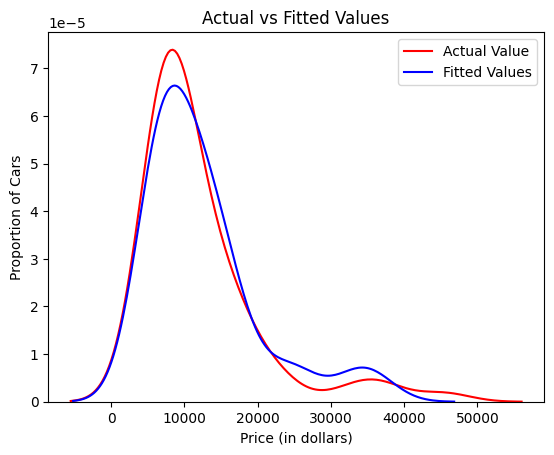

In [76]:
plot_dis(y_test,predicted_y_baseline_lm)

Below, we will view the estimated coefficients for the linear regression problem.


In [77]:
coef_series = pd.Series(baseline_all_features_lm.coef_, index=X.columns)
abs_coef_series = coef_series.abs().sort_values(ascending=False)

print("Largest coefficients by absolute value:")
display(abs_coef_series.head(10))


Largest coefficients by absolute value:


dohcv          19132.752011
eight          11778.528178
ohcf            8718.958706
four            7061.924547
ohc             6439.788400
five            3915.390372
l               3825.616837
dohc            3750.769092
ohcv            3695.522922
convertible     2566.951788
dtype: float64

From the ranked list above, we can identify the largest coefficients by absolute value. If we plot all coefficients on the same scale, those largest values will compress the rest of the bars and make smaller coefficients hard to compare.

So in the next cell, we remove the **two largest coefficients by absolute value** and plot the remainder.


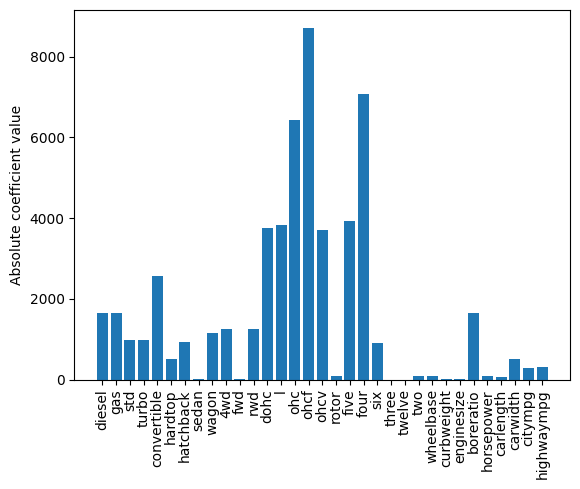

In [78]:
remaining_coef = coef_series.drop(abs_coef_series.index[:2])

plt.bar(remaining_coef.index, remaining_coef.abs())
plt.xticks(rotation=90)
plt.ylabel("Absolute coefficient value")
plt.show()

Usually, larger coefficients are often interpreted as having stronger influence on prediction, but this is not always reliable. To verify importance more carefully, let's look at single-feature performance.


### Individual Features 


We can train the model and plot our $R^2$ for each of the features on the training and testing data sets, using the function <code>get_single_feature_r2</code>.


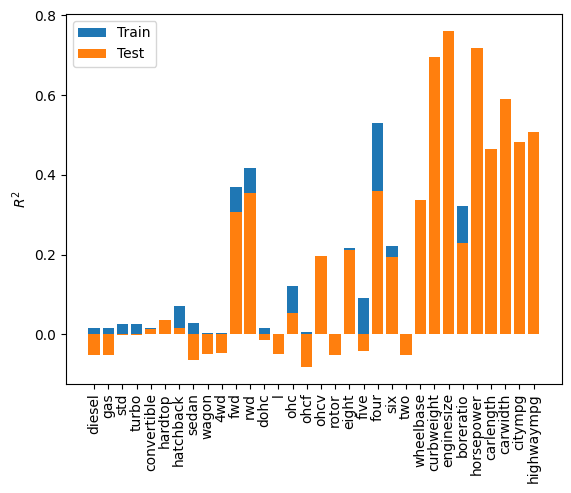

Excluded ultra-rare indicators: ['three', 'dohcv', 'twelve']
Training R^2 mean value 0.21780519883849941 Testing R^2 mean value 0.1864786275250123 
Training R^2 max value 0.755391074877049 Testing R^2 max value 0.7617118860979702 


In [79]:
get_single_feature_r2(baseline_all_features_lm)

From the plot above, some individual features perform similarly to using all features.

In this comparison, we excluded ultra-rare binary indicators (currently `three`, `dohcv`, and `twelve`) based on the audit rule (positive rate < 1%). This makes single-feature $R^2$ results more stable and interpretable.

Also note: a larger coefficient does **not** always imply better standalone predictive performance. In several cases, smaller coefficients correspond to higher single-feature $R^2$.


## Pipeline-Based Linear Regression (Scaling + Model)
In this section, we repeat the same all-feature linear regression setup from the previous section, but now we run it through a `Pipeline` that applies `StandardScaler()` before `LinearRegression`.

This lets us compare a direct model fit vs a reproducible preprocessing + modeling workflow using the same train/test split.

### What is Pipeline?
In machine learning, we often need to run multiple steps in order (for example, scaling then modeling). A `Pipeline` object in scikit-learn chains these steps so they run in a fixed, repeatable sequence.
**Example**: `Pipeline([('ss', StandardScaler()), ('lr', LinearRegression())])` means:
  1. scale the input features
  2. train a linear regression model on the scaled features

### What the Next Code Cell Does
- Build the pipeline (`StandardScaler` -> `LinearRegression`)
- Fit the pipeline on `X_train, y_train`
- Compute training and testing $R^2$
- Predict `y` values for `X_test`
- Plot predicted vs actual distributions

R^2 on training data using pipeline: 0.9198461581436516
R^2 on testing data using pipeline: 0.8634323104754111


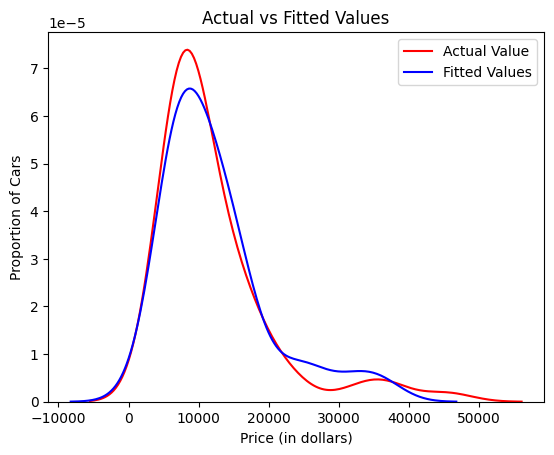

In [80]:
pipe = Pipeline([('ss', StandardScaler()), ('lr', LinearRegression())])
pipe.fit(X_train, y_train)  # fit pipeline on training data

print("R^2 on training data using pipeline:", pipe.score(X_train, y_train))  # print training R-squared
print("R^2 on testing data using pipeline:", pipe.score(X_test, y_test))  # print testing R-squared
predicted_y_pipe = pipe.predict(X_test)  # generate test predictions from pipeline
plot_dis(y_test, predicted_y_pipe)  # plot actual vs predicted distributions

In [81]:
#Comparing with baseline linear regression model with all features 
print("R^2 on training data using baseline model:", baseline_r2_train)
print("R^2 on testing data using baseline model:", baseline_r2_test)

R^2 on training data using baseline model: 0.9198461581436516
R^2 on testing data using baseline model: 0.8729993731695591


## Exercise 3: Pipeline Performance by Individual Feature
In this exercise, we apply the same `Pipeline` idea, but now we evaluate **one feature at a time** using `get_single_feature_r2(pipe)`.

### Important comparison note (Cell 49 vs Cell 52)
- **Cell 49** reports $R^2$ for one pipeline trained on **all features together**.
- **Cell 52** trains many separate pipelines, each using **only one feature**, then reports the **mean** and **max** $R^2$ across those single-feature runs.

Because these are different evaluation setups, their $R^2$ values are not directly expected to match. The lower mean in Cell 52 is normal: many individual features are weak alone, while combining features in Cell 49 captures more signal.

Rare-column exclusion is a secondary effect here; the main reason for the difference is **all-feature model vs single-feature models**.

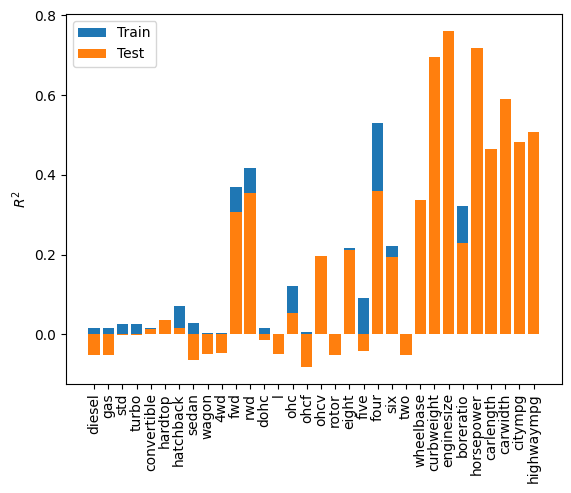

Excluded ultra-rare indicators: ['three', 'dohcv', 'twelve']
Training R^2 mean value 0.21780519883849941 Testing R^2 mean value 0.18647862752501226 
Training R^2 max value 0.7553910748770489 Testing R^2 max value 0.76171188609797 


In [82]:
# Enter your code and run the cell
pipe = Pipeline([('ss',StandardScaler() ),('lr', LinearRegression())])
get_single_feature_r2(pipe)

## Polynomial Features

### Multiple Features

Polynomial transform is a simple way to increase model complexity by generating new features from existing ones. However, we must stay alert to overfitting when degree increases.

---

### Key Terminology

- **`PolynomialFeatures`**: A scikit-learn transformer that creates new features by computing polynomial combinations of the original features. For example, with one feature $x$, degree=2 produces $x$ and $x^2$. With two features $x_1$ and $x_2$, it produces $x_1$, $x_2$, $x_1^2$, $x_1x_2$, and $x_2^2$.

- **`degree=2`**: The maximum polynomial degree to generate. Degree 2 adds squared terms and cross-product terms; degree 3 adds cubic terms and more interactions. Higher degrees rapidly increase feature count and overfitting risk.

- **`include_bias=False`**: Controls whether a constant column of 1s (bias/intercept term) is included. We set it to `False` here because `LinearRegression` already handles the intercept.

- **`fit_transform(X_train)`**: Learns the polynomial feature structure from training data, then applies it to produce transformed training features.

- **`transform(X_test)`**: Applies the already-learned mapping to test data with no re-learning. Correct pattern: **fit on train, transform both train and test**.

---

### What the Next Code Cells Do

```python
poly_features = PolynomialFeatures(degree=2, include_bias=False)
```
Creates a transformer that generates degree-2 polynomial features (squared terms and interactions), without adding a bias column.

```python
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly  = poly_features.transform(X_test)
```
- `X_train_poly` contains the original 35 features **plus** all squared and cross-product terms, resulting in 665 total features.
- `X_test_poly` is transformed using the same mapping learned from `X_train`, so train and test structures remain consistent.


In [83]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

`X_train_poly` and `X_test_poly` now include the original features plus polynomial interaction terms.

Let's check the shape of the newly created train and test sets in the next code cell.

In [84]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_train_poly: {X_train_poly.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of X_test_poly: {X_test_poly.shape}")

Shape of X_train: (143, 35)
Shape of X_train_poly: (143, 665)
Shape of X_test: (62, 35)
Shape of X_test_poly: (62, 665)


### Why did the number of columns increase from 35 to 665?

With degree-2 polynomial expansion, we keep original features and add:
- all squared terms (for example, $x_1^2, x_2^2, \dots$)
- all pairwise interaction terms (for example, $x_1x_2, x_1x_3, \dots$)

For $n$ original features with degree=2 and `include_bias=False`, total columns are:
$$
n + \frac{n(n-1)}{2} + n = n + \frac{n(n+1)}{2}
$$

If $n=35$:
$$
35 + \frac{35 \cdot 36}{2} = 35 + 630 = 665
$$

So the transformed shapes are correctly larger than the original train/test feature matrices.

### Potential Benefit

- Captures non-linear patterns while still using a linear model.
- Can improve predictive performance when relationships are curved or interaction-driven.

### Potential Costs

- **Overfitting risk**: many new features can fit noise, especially with limited samples.
- **Higher compute and memory usage**: training and prediction are heavier with many columns.
- **Lower interpretability**: coefficients are harder to explain with many interaction terms.

Now, we will fit the model on polynomial features and compare train/test performance.


In [85]:
lm = LinearRegression()
lm.fit(X_train_poly, y_train)
predicted = lm.predict(X_train_poly)

Again, we can check `r2_score()` on both training and testing data sets.


In [86]:
print("R^2 on training data:", lm.score(X_train_poly, y_train))
print("R^2 on testing data:", lm.score(X_test_poly,y_test))

R^2 on training data: 0.9989728976727738
R^2 on testing data: -29033.467044962283


We see the model has a negative $R^{2}$ on the test data set, this is sign of overfiting.


### Individual Features

In the next code cell, we build a **Pipeline** so polynomial transformation and model training happen in one reproducible flow.

### What the Next Code Cell Does

```python
Input=[ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('model', LinearRegression())]
pipe=Pipeline(Input)
pipe.fit(X_train, y_train)
```

1. `Input=[...]` defines the pipeline steps in order:
- `polynomial`: creates degree-2 polynomial features (squares + interaction terms).
- `model`: fits a `LinearRegression` model on those transformed features.

2. `pipe=Pipeline(Input)` creates a single estimator object that chains both steps.

3. `pipe.fit(X_train, y_train)` trains the full pipeline on training data:
- first transforms `X_train` internally using `PolynomialFeatures`
- then fits `LinearRegression` on the transformed matrix

### Why this is useful

- Cleaner code: preprocessing + model are tied together in one object.
- Safer workflow: the same transformation is automatically reused at prediction/scoring time.
- Easier experimentation: we can tune the existing `pipe` later without rewriting the training logic.

In [87]:
Input=[ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('model', LinearRegression())]

# We can repeat the steps above, using the <code>Pipleine</code> object.
pipe=Pipeline(Input)
pipe.fit(X_train, y_train)

,steps,"[('polynomial', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


We can see that the results are identical to the polynomial-fit approach. This is because both methods fit the same mathematical model on the same data; they only differ in code organization.


In [88]:
print("R^2 on training  data:", pipe.score(X_train, y_train))
print("R^2 on testing data:", pipe.score(X_test,y_test))

R^2 on training  data: 0.9989728976727738
R^2 on testing data: -29033.467044962283


We can train our model on each of the features using the Polynomial Feature transform of the second degree. Then we can plot our $R^2$. 


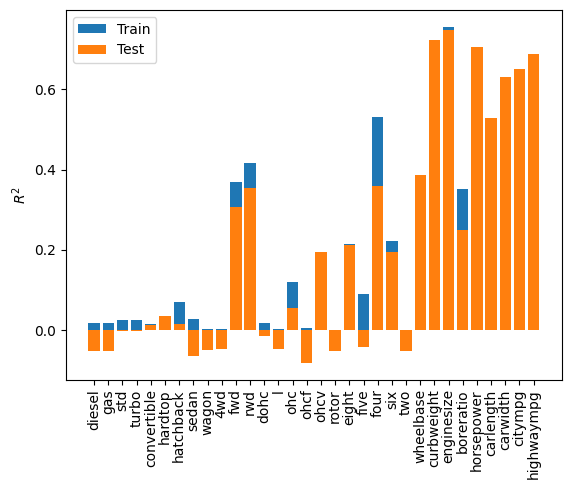

Excluded ultra-rare indicators: ['three', 'dohcv', 'twelve']
Training R^2 mean value 0.23092787027942452 Testing R^2 mean value 0.20291679539289065 
Training R^2 max value 0.7562187834197522 Testing R^2 max value 0.7489019655649904 


In [89]:
get_single_feature_r2(pipe)

Feature with the max $R^{2}$ is higher than when using all the features.


## GridSearch and Pipeline

In this section, we move from fitting one fixed pipeline to **tuning** a pipeline automatically.

### Difference from the previous step

- We add a new first step: `StandardScaler()`.
- So the model flow becomes: **scale features -> create polynomial features -> fit linear regression**.
- Earlier, we used only: **create polynomial features -> fit linear regression**.

Why this matters: scaling helps keep feature magnitudes comparable, which can improve numerical stability and make tuning more reliable when we compare many settings.

### New terminology introduced in this section

- **Hyper-parameters**: Settings chosen before training (for example, polynomial degree). They are not learned directly from data.
- **Parameter grid (`param_grid`)**: A dictionary listing candidate hyper-parameter values to try.
- **Cross-validation**: Repeated train/validation splits used to estimate generalization more robustly than a single split.
- **`GridSearchCV`**: A tool that tries all combinations from the parameter grid and uses cross-validation to select the best-performing setup.

In short: compared with the previous step, we now include scaling and prepare the pipeline to be optimized automatically with GridSearch + cross-validation instead of using one manually fixed configuration.

<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/images/k-fold.png">
</center>
<center>source scikit-learn.org</center>


We now create a pipeline with scaling, polynomial transformation, and linear regression.

In [90]:
Input=[ ('scaler', StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('model',LinearRegression())]

pipe=Pipeline(Input)

In the next code cell, we define hyper-parameter values and create a `GridSearchCV` object.

### What the Next Code Cell Does

1. `param_grid` lists candidate values to test.
- Here, we test polynomial degrees `1`, `2`, and `3`.
- These are **hyper-parameters** because we set them before training.

2. `"polynomial__degree"` uses pipeline naming rules.
- `polynomial` is the pipeline step name.
- `degree` is the parameter inside `PolynomialFeatures`.
- `__` tells scikit-learn to set a parameter inside a specific step.

3. `search = GridSearchCV(pipe, param_grid, cv=5, n_jobs=1)` creates the search object.
- It evaluates all degree choices using 5-fold cross-validation on training data.
- The best configuration is chosen by average validation performance across folds.

4. `search.fit(X_train, y_train)` runs the grid search **only on training data**.
- This avoids data leakage.
- The test set remains untouched for final evaluation.

### Key idea

Instead of manually choosing one degree, we let `GridSearchCV` compare options on training folds, then evaluate the selected model once on the held-out test set.

In [91]:
param_grid = {
    "polynomial__degree": [1, 2, 3]
}

search = GridSearchCV(pipe, param_grid, cv=5, n_jobs=1)
search.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'polynomial__degree': [1, 2, ...]}"
,scoring,None
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


The object finds the best parameter values using cross-validation on the training set. We can obtain the estimator with the best parameters and assign it to `best`.

In [92]:
best=search.best_estimator_
best

,steps,"[('scaler', ...), ('polynomial', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,degree,1
,interaction_only,False
,include_bias,False
,order,'C'


Inspect the output above to see the selected polynomial degree and model settings chosen by cross-validation.


Now, we test our model on the test data to see the best score.


In [93]:
best.score(X_test,y_test)

0.8634323104754117

Finally, we can plot a distribution of the predicted values versus the actual values. 


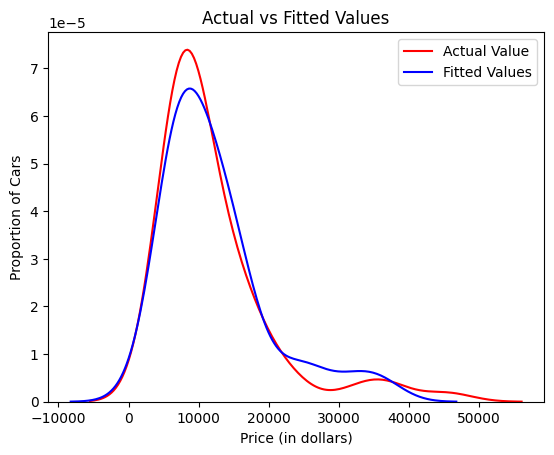

In [94]:
predicted_best=best.predict(X_test)
plot_dis(y_test,predicted_best)

Interpret this plot together with the train/test $R^2$: if predicted and actual distributions align reasonably well and test $R^2$ is not far below training $R^2$, the model is generalizing better.


## Exercise 4
In this exercise, calculate $R^2$ using a `Pipeline` with `GridSearchCV` for each individual feature.

Use the **same rare-indicator rule** from earlier: for single-feature comparisons, exclude binary columns with positive rate < 1%.


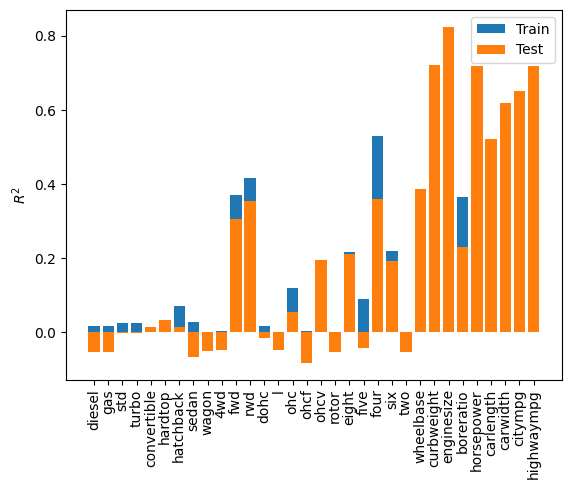

Excluded ultra-rare indicators: ['three', 'dohcv', 'twelve']
Training R^2 mean value 0.23227397061952182 Testing R^2 mean value 0.20517931840530074
Training R^2 max value 0.7758142451525096 Testing R^2 max value 0.8243157920117452


In [95]:
if "sparsity" in globals() and {"rare"}.issubset(sparsity.columns):
    excluded_features = sparsity.index[sparsity["rare"]].tolist()
else:
    excluded_features = ["three", "dohcv", "twelve"]

features = [f for f in X.columns if f not in excluded_features]

R_2_train = []
R_2_test = []

for feature in features:
    param_grid = {
        "polynomial__degree": [1, 2, 3, 4, 5],
        "model__positive": [True, False]
    }

    Input = [
        ('polynomial', PolynomialFeatures(include_bias=False, degree=2)),
        ('model', LinearRegression())
    ]
    pipe = Pipeline(Input)

    search = GridSearchCV(pipe, param_grid, n_jobs=2)
    search.fit(X_train[[feature]], y_train)
    best = search.best_estimator_

    R_2_test.append(best.score(X_test[[feature]], y_test))
    R_2_train.append(best.score(X_train[[feature]], y_train))

plt.bar(features, R_2_train, label="Train")
plt.bar(features, R_2_test, label="Test")
plt.xticks(rotation=90)
plt.ylabel("$R^2$")
plt.legend()
plt.show()

print("Excluded ultra-rare indicators:", [f for f in excluded_features if f in X.columns])
print("Training R^2 mean value {} Testing R^2 mean value {}".format(str(np.mean(R_2_train)), str(np.mean(R_2_test))))
print("Training R^2 max value {} Testing R^2 max value {}".format(str(np.max(R_2_train)), str(np.max(R_2_test))))

## Conclusion

In this notebook, we compared linear regression and polynomial regression for predicting car prices.

### Key takeaways

- A **baseline linear regression** using all features produced reasonable training and testing performance.
- Adding **feature scaling** with a pipeline made the workflow cleaner, but did not fundamentally change model quality.
- Expanding all features to **degree-2 polynomial terms** greatly increased model complexity and caused **overfitting**, shown by very high training $R^2$ and poor test $R^2$.
- In **single-feature analysis**, some variables such as `enginesize`, `curbweight`, `horsepower`, and mileage-related features were much more informative than others.
- Using **GridSearchCV** with cross-validation selected the best polynomial degree more responsibly. In this case, the best pipeline chose a **simpler model** (`degree=1`), showing that higher complexity did not improve generalization.
- Excluding **ultra-rare indicator columns** (`three`, `dohcv`, `twelve`) made single-feature comparisons more stable and interpretable.

### Final conclusion

The main lesson is that **more complex models are not always better**. Polynomial features can capture nonlinear relationships, but they can also fit noise when the feature space grows too large relative to the dataset size. For this dataset, the evidence suggests that a **simpler linear model generalizes better** than a high-degree polynomial model. Prefer the **simplest model that performs well on unseen data**, and use **cross-validation** rather than training performance alone when choosing model complexity.

<!--## Change Log
-->


<!--| Date (YYYY-MM-DD) | Version | Changed By            | Change Description                   |
| ----------------- | ------- | --------------------- | ------------------------------------ |
|   2022-04-15      | 0.1     | Svitlana K.           | Created the first draft |
|   2022-04-18      | 0.1     | Joseph S.             | Updated all content |
|   2022-04-26      | 0.1     | Svitlana K.           | Corrected minor grammar errors |-->

